<a href="https://colab.research.google.com/github/eGamez01/solar_system_simulator/blob/demand-dist/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solar System Simulator

## Demand

### Read Usage Data

In [18]:
# ───────────────────────────────────────────────────────────────
# 0.  Colab prep  – install (once per runtime)
# ───────────────────────────────────────────────────────────────
# !pip install --quiet beautifulsoup4 lxml requests

import pandas as pd
from bs4 import BeautifulSoup
import requests
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 4)

# ───────────────────────────────────────────────────────────────
# 1.  GitHub RAW base URL (main branch) + relative paths
# ───────────────────────────────────────────────────────────────
base_raw = (
    "https://raw.githubusercontent.com/"
    "eGamez01/solar_system_simulator/"
    "refs/heads/main/data/"
)

file_paths = [
    "20240701-20250630/CPS_Electric_15_Minute_06-27-2025_07-01-2025_20250705183845810_8042694_Formatted.html",
    "20240701-20250630/CPS_Electric_15_Minute_07-01-2024_12-28-2024_20250705183711125_8042694_Formatted.html",
    "20240701-20250630/CPS_Electric_15_Minute_12-28-2024_06-27-2025_20250705183833108_8042694_Formatted.html",
]

raw_urls = [base_raw + p for p in file_paths]

# ───────────────────────────────────────────────────────────────
# 2.  Parse a remote CPS Green-Button HTML file → DataFrame
#      columns = start (datetime), usage_wh (int)
# ───────────────────────────────────────────────────────────────
def parse_remote_html(url: str) -> pd.DataFrame:
    soup = BeautifulSoup(requests.get(url, timeout=30).text, "lxml")
    rows = []
    for tr in soup.find_all("tr"):
        tds = tr.find_all("td")
        if len(tds) != 3:
            continue
        usage_txt = tds[1].get_text(strip=True).replace(",", "")
        if not usage_txt.isdigit():
            continue
        period = tds[0].get_text(" ", strip=True).replace("\u00a0", " ")
        if " to " not in period:
            continue
        start_dt = pd.to_datetime(period.split(" to ")[0], errors="coerce")
        if pd.notna(start_dt):
            rows.append((start_dt, int(usage_txt)))
    return pd.DataFrame(rows, columns=["start", "usage_wh"])

# ───────────────────────────────────────────────────────────────
# 3.  Load all files, **then keep only FULL calendar months**
#     (drops the partial months June-2024 and July-2025)
# ───────────────────────────────────────────────────────────────
# 3-a  combine 15-minute rows
usage_15min = (
    pd.concat([parse_remote_html(u) for u in raw_urls], ignore_index=True)
    .sort_values("start")
)

# 3-b  tag each row with date & month
usage_15min["date"]  = usage_15min["start"].dt.date
usage_15min["month"] = usage_15min["start"].dt.to_period("M")

# 3-c  find months that have every day present
days_per_month = usage_15min.groupby("month")["date"].nunique()
full_months    = days_per_month[
    days_per_month == days_per_month.index.to_timestamp().days_in_month
].index

# 3-d  filter to those months
usage_15min = usage_15min[usage_15min["month"].isin(full_months)].copy()

# (optional) clean up helper columns
usage_15min.drop(columns=["date", "month"], inplace=True)

# ───────────────────────────────────────────────────────────────
# 4.  Sanity check: list the months that made the cut
# ───────────────────────────────────────────────────────────────
print("Full months retained:", [str(m) for m in full_months])


Full months retained: ['2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06']


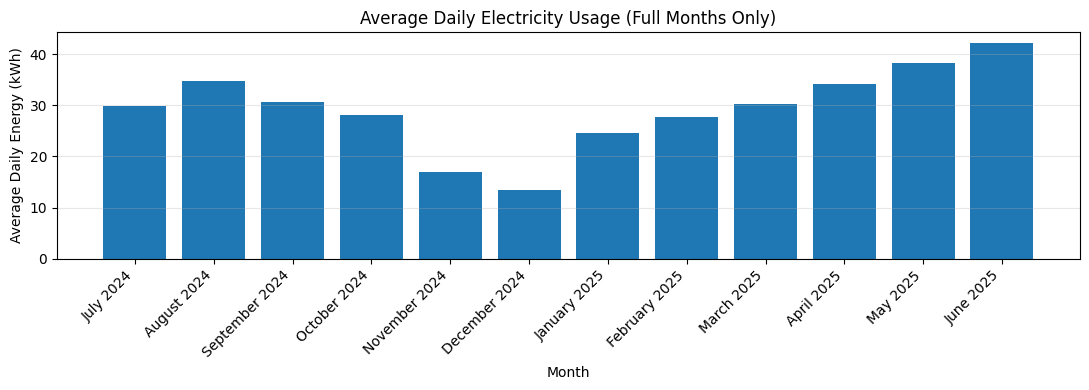

In [19]:
# ───────────────────────────────────────────────────────────────
# NEW BLOCK  ▸  Average daily kWh by month (full-months only)
#   • uses `usage_15min` that already has partial months removed
# ───────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣  daily kWh totals
daily_usage = (
    usage_15min
    .assign(date=lambda d: d["start"].dt.date)
    .groupby("date", as_index=False)["usage_wh"]
    .sum()
    .assign(usage_kwh=lambda d: d["usage_wh"] / 1000.0)
)

# 2️⃣  tag each day with calendar month
daily_usage["month"] = pd.to_datetime(daily_usage["date"]).dt.to_period("M")

# 3️⃣  identify which of those months are still “full” (all days present)
days_per_month = daily_usage.groupby("month")["date"].nunique()
full_months    = days_per_month.index[
    days_per_month == days_per_month.index.to_timestamp().days_in_month
]

# 4️⃣  compute average daily kWh in each full month
monthly_avg = (
    daily_usage[daily_usage["month"].isin(full_months)]
    .groupby("month", as_index=False)["usage_kwh"]
    .mean()
    .assign(
        month_start=lambda d: d["month"].dt.to_timestamp(),
        label=lambda d: d["month_start"].dt.strftime("%B %Y")
    )
)

# 5️⃣  plot
plt.figure(figsize=(11, 4))
plt.bar(monthly_avg["label"], monthly_avg["usage_kwh"])
plt.title("Average Daily Electricity Usage (Full Months Only)")
plt.xlabel("Month")
plt.ylabel("Average Daily Energy (kWh)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Vis Data

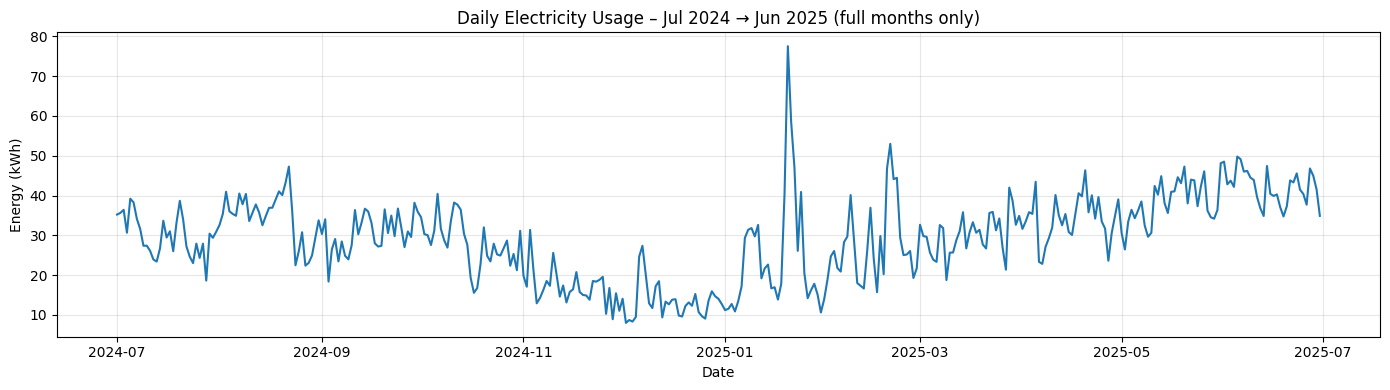

In [20]:
# ───────────────────────────────────────────────────────────────
# 3.  Load all files  →  keep only FULL calendar months
#     (drops June-2024 and July-2025 partial data)
# ───────────────────────────────────────────────────────────────
dfs         = [parse_remote_html(u) for u in raw_urls]
usage_15min = pd.concat(dfs, ignore_index=True).sort_values("start")

# ── tag each row with date + month
usage_15min["date"]  = usage_15min["start"].dt.date
usage_15min["month"] = usage_15min["start"].dt.to_period("M")

# ── determine which months are complete
days_per_month = usage_15min.groupby("month")["date"].nunique()
full_months    = days_per_month[
    days_per_month == days_per_month.index.to_timestamp().days_in_month
].index

# ── filter down to those months only
usage_15min = usage_15min[usage_15min["month"].isin(full_months)].copy()

# ───────────────────────────────────────────────────────────────
# 4.  Aggregate to daily kWh and plot demand curve
# ───────────────────────────────────────────────────────────────
daily_usage = (
    usage_15min
    .groupby("date", as_index=False)["usage_wh"].sum()
    .assign(usage_kwh=lambda d: d["usage_wh"] / 1000.0)
)

plt.plot(pd.to_datetime(daily_usage["date"]), daily_usage["usage_kwh"])
plt.title("Daily Electricity Usage – Jul 2024 → Jun 2025 (full months only)")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  daily_usage now contains 365 rows (01 Jul 2024 – 30 Jun 2025)


/tmp/ipython-input-21-51997690.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")["usage_wh"]


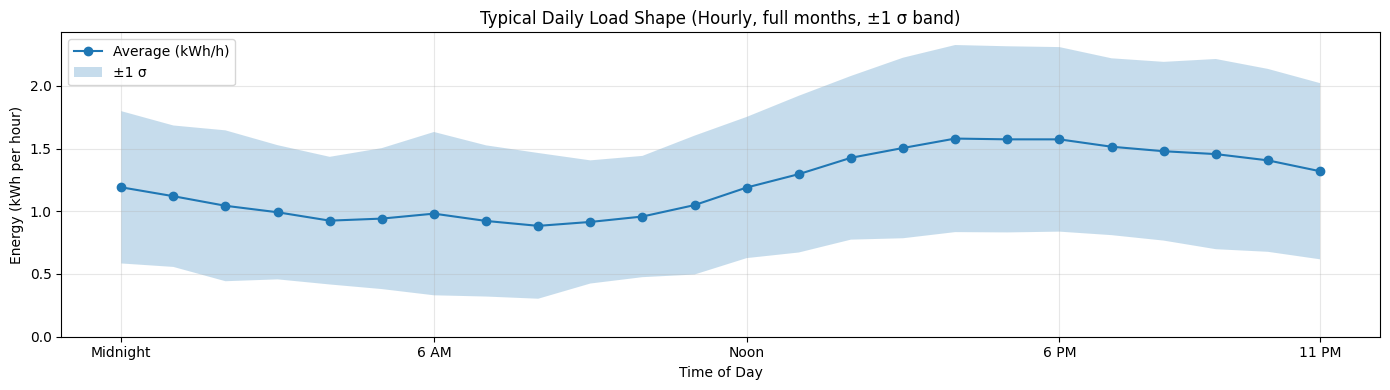

In [21]:
# ───────────────────────────────────────────────────────────────
# NEW BLOCK  ▸  Hourly load shape (mean ± 1 σ) – full-month data
# ───────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1.  Collapse 15-minute rows → hourly Wh
usage_hourly = (
    usage_15min
    .set_index("start")
    .resample("H")["usage_wh"]
    .sum()
    .reset_index()
)

# 2.  Hour-of-day key (0-23)
usage_hourly["hour"] = usage_hourly["start"].dt.hour

# 3.  Mean & std across the (full-month) year
profile_hr = (
    usage_hourly
    .groupby("hour")["usage_wh"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "mean_wh", "std": "std_wh"})
    .assign(mean_kwh=lambda d: d["mean_wh"] / 1000.0,
            std_kwh=lambda d:  d["std_wh"]  / 1000.0)
)

hours = np.arange(24)

# 4.  Plot mean ± 1 σ
plt.plot(hours, profile_hr["mean_kwh"], marker="o", label="Average (kWh/h)")
plt.fill_between(
    hours,
    profile_hr["mean_kwh"] - profile_hr["std_kwh"],
    profile_hr["mean_kwh"] + profile_hr["std_kwh"],
    alpha=0.25,
    label="±1 σ"
)

# 5.  Friendlier clock labels
plt.xticks([0, 6, 12, 18, 23], ["Midnight", "6 AM", "Noon", "6 PM", "11 PM"])

plt.title("Typical Daily Load Shape (Hourly, full months, ±1 σ band)")
plt.xlabel("Time of Day")
plt.ylabel("Energy (kWh per hour)")
plt.ylim(bottom=0)                 # y-axis starts at 0
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


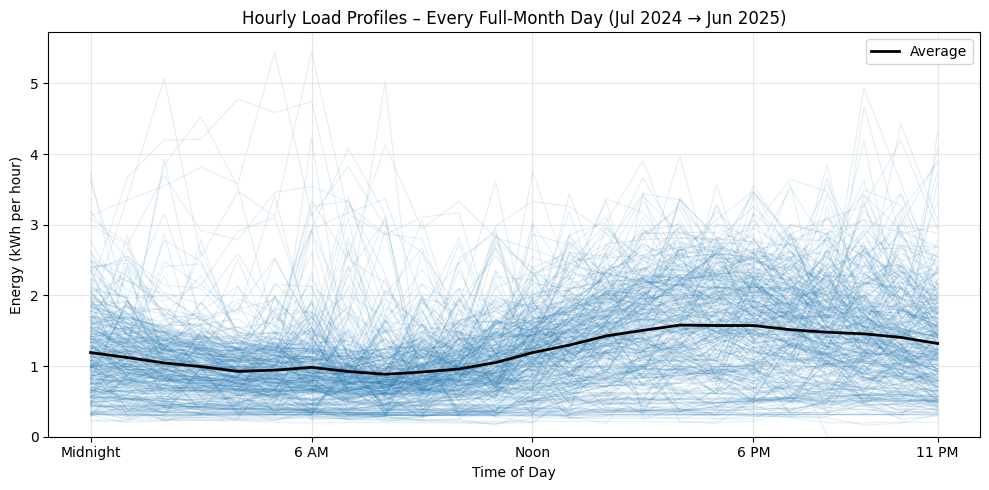

In [22]:
# ───────────────────────────────────────────────────────────────
# NEW BLOCK  ▸  “Spaghetti” plot – every day’s 24-hour profile
#              (only full-month data, hourly resolution)
# ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣  ensure calendar date column
usage_hourly["date"] = usage_hourly["start"].dt.date

# 2️⃣  24 × N_days matrix  (Wh → kWh)
pivot_kwh = (
    usage_hourly
    .pivot_table(index="hour", columns="date", values="usage_wh", aggfunc="sum")
    .sort_index(axis=0)   # rows 0‒23
    / 1000.0              # kWh
)

hours = np.arange(24)

plt.figure(figsize=(10, 5))

# 3️⃣  plot each day as a faint line
for col in pivot_kwh.columns:
    plt.plot(hours, pivot_kwh[col], color="tab:blue", alpha=0.12, lw=0.8)

# 4️⃣  overlay mean profile
plt.plot(hours, pivot_kwh.mean(axis=1), color="black", lw=2, label="Average")

# 5️⃣  nicer x-ticks
plt.xticks([0, 6, 12, 18, 23], ["Midnight", "6 AM", "Noon", "6 PM", "11 PM"])

plt.title("Hourly Load Profiles – Every Full-Month Day (Jul 2024 → Jun 2025)")
plt.xlabel("Time of Day")
plt.ylabel("Energy (kWh per hour)")
plt.ylim(bottom=0)           # start y-axis at 0
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Supply

In [24]:
# ───────────────────────────────────────────────────────────────
# NEW BLOCK  ▸  Securely capture / reuse your NREL API key
#   • Never hard-codes the key in the notebook or repository.
#   • Looks in env-vars → ~/.nrel_api_key → prompts user.
#   • Optional one-time save to a hidden file outside your repo.
# ───────────────────────────────────────────────────────────────
from getpass import getpass
from pathlib import Path
import os

# Where to stash the key locally (home dir, NOT your repo):
cred_path = Path.home() / ".nrel_api_key"


def get_nrel_key() -> str:
    """Return an NREL API key, loading / prompting as needed."""

    # 1️⃣  Already in this Colab / Python env?
    if "NREL_API_KEY" in os.environ and os.environ["NREL_API_KEY"].strip():
        return os.environ["NREL_API_KEY"].strip()

    # 2️⃣  Previously saved to ~/.nrel_api_key ?
    if cred_path.exists():
        key = cred_path.read_text().strip()
        os.environ["NREL_API_KEY"] = key
        return key

    # 3️⃣  Prompt the user (value hidden as they type)
    key = getpass("Enter your NREL API key: ").strip()

    # (Optional) offer to save for future sessions
    save = input("Save key locally for future sessions? [y/N]: ").lower() == "y"
    if save:
        cred_path.write_text(key)
        cred_path.chmod(0o600)  # owner-read/write only
        print(f"Key stored at {cred_path} (and auto-loaded next time).")

    os.environ["NREL_API_KEY"] = key
    return key


# Call once at the top of any notebook that needs NREL data:
NREL_API_KEY = get_nrel_key()
print("NREL_API_KEY ready (not printed for security).")


Enter your NREL API key: ··········
Save key locally for future sessions? [y/N]: N
NREL_API_KEY ready (not printed for security).


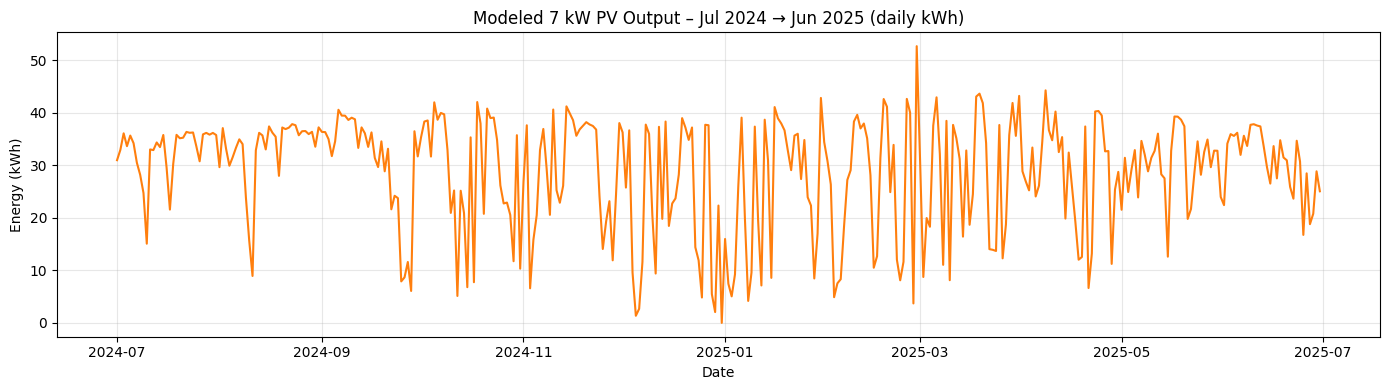

In [27]:
# ───────────────────────────────────────────────────────────────
# NEW BLOCK  ▸  7 kW PV output – fixed unit conversion (W → kWh)
# ───────────────────────────────────────────────────────────────
import pandas as pd
import requests
import matplotlib.pyplot as plt

NREL_API_KEY = get_nrel_key()

pv_params = {
    "api_key":        NREL_API_KEY,
    "lat":            29.42,
    "lon":           -98.49,
    "timeframe":      "hourly",
    "system_capacity": 7.0,   # kW-dc
    "azimuth":        180,
    "tilt":           30,
    "module_type":    1,
    "array_type":     1,
    "losses":         14
}

resp = requests.get(
    "https://developer.nrel.gov/api/pvwatts/v8.json",
    params=pv_params,
    timeout=30
).json()

if resp.get("errors"):
    raise RuntimeError(resp["errors"])

# ── convert W → kWh (kW · 1 h)
ac_kwh_hourly = [w / 1000 for w in resp["outputs"]["ac"]]   # 8 760 values

hours_8760 = pd.date_range("2024-01-01 00:00", periods=8760, freq="h")
pv_hourly   = pd.DataFrame({"ac_kwh": ac_kwh_hourly}, index=hours_8760)

# stitch Jul-Dec 2024 + Jan-Jun 2025
pv_supply = pd.concat([
    pv_hourly.loc["2024-07-01":"2024-12-31"],
    pv_hourly.loc["2024-01-01":"2024-06-30"].rename(
        index=lambda ts: ts + pd.DateOffset(years=1)
    )
]).sort_index()

pv_daily = (
    pv_supply
    .resample("D")
    .sum()
    .rename(columns={"ac_kwh": "pv_kwh"})
)

# plot
plt.figure(figsize=(14, 4))
plt.plot(pv_daily.index, pv_daily["pv_kwh"], color="tab:orange")
plt.title("Modeled 7 kW PV Output – Jul 2024 → Jun 2025 (daily kWh)")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


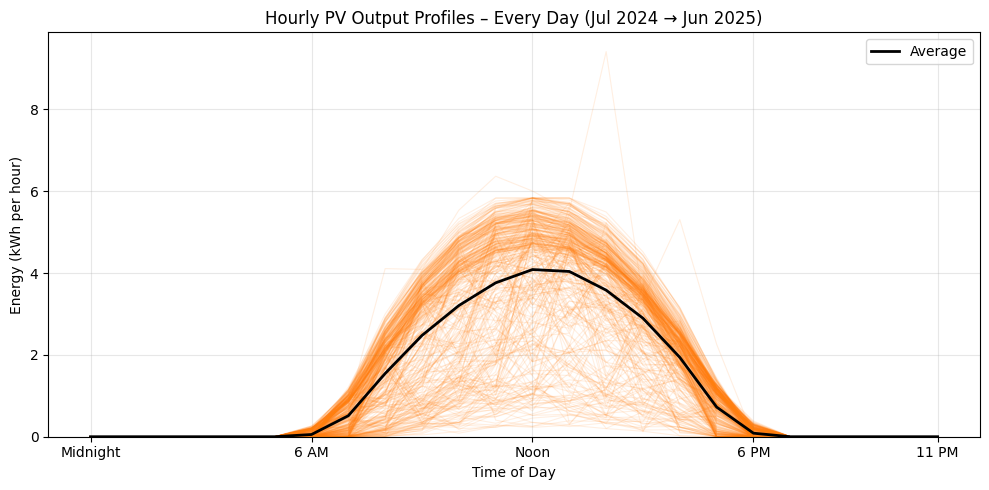

In [28]:
# ───────────────────────────────────────────────────────────────
# NEW BLOCK  ▸  “Spaghetti” plot – each day’s PV supply profile
#   (assumes `pv_supply` from the PVWatts block ─ index = hourly
#    timestamps, column = ac_kwh  … covering 1 Jul 2024–30 Jun 2025)
# ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣  Hour & calendar-date keys
pv_supply = pv_supply.copy()               # ensure we don’t mutate original
pv_supply["hour"] = pv_supply.index.hour
pv_supply["date"] = pv_supply.index.date

# 2️⃣  24×365 matrix  (rows = hour, cols = date)  – kWh/h already
pivot_pv = (
    pv_supply
    .pivot_table(index="hour", columns="date", values="ac_kwh", aggfunc="sum")
    .sort_index(axis=0)          # ensure hour 0-23 order
)

hours = np.arange(24)

plt.figure(figsize=(10, 5))

# 3️⃣  plot each day’s curve (faint orange)
for col in pivot_pv.columns:
    plt.plot(hours, pivot_pv[col], color="tab:orange", alpha=0.12, lw=0.8)

# 4️⃣  overlay mean PV profile
plt.plot(hours, pivot_pv.mean(axis=1), color="black", lw=2, label="Average")

# 5️⃣  clock labels
plt.xticks([0, 6, 12, 18, 23], ["Midnight", "6 AM", "Noon", "6 PM", "11 PM"])

plt.title("Hourly PV Output Profiles – Every Day (Jul 2024 → Jun 2025)")
plt.xlabel("Time of Day")
plt.ylabel("Energy (kWh per hour)")
plt.ylim(bottom=0)                 # start at 0 kWh
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


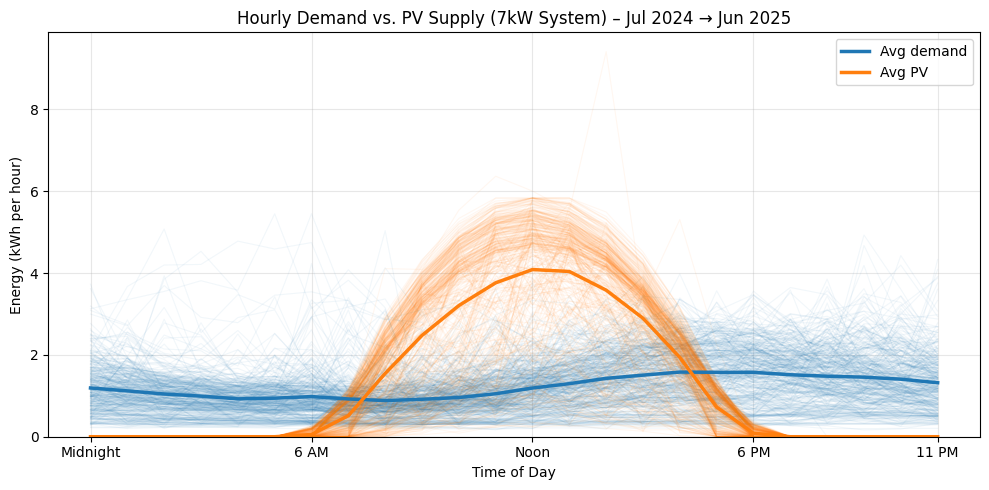

In [30]:
# ───────────────────────────────────────────────────────────────
# NEW BLOCK  ▸  Overlay: hourly demand **and** PV supply profiles
#              (spaghetti + mean lines)
#   • needs `usage_hourly`  (demand)  and  `pv_supply` (supply)
# ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# ── build 24×N matrices for demand & supply
# 1️⃣  demand
pivot_dem = (
    usage_hourly
    .pivot_table(index="hour", columns=usage_hourly["start"].dt.date,
                 values="usage_wh", aggfunc="sum")
    .sort_index() / 1000.0                       # kWh per hour
)

# 2️⃣  supply
pivot_pv = (
    pv_supply
    .pivot_table(index="hour", columns=pv_supply.index.date,
                 values="ac_kwh", aggfunc="sum")
    .sort_index()
)

hours = np.arange(24)
plt.figure(figsize=(10, 5))

# ── spaghetti  (faint)
for col in pivot_dem.columns:
    plt.plot(hours, pivot_dem[col], color="tab:blue",   alpha=0.06, lw=0.8)
for col in pivot_pv.columns:
    plt.plot(hours, pivot_pv[col], color="tab:orange", alpha=0.06, lw=0.8)

# ── mean curves  (bold)
plt.plot(hours, pivot_dem.mean(axis=1), color="tab:blue",   lw=2.5, label="Avg demand")
plt.plot(hours, pivot_pv.mean(axis=1), color="tab:orange", lw=2.5, label="Avg PV")

# x-axis labels
plt.xticks([0, 6, 12, 18, 23], ["Midnight", "6 AM", "Noon", "6 PM", "11 PM"])

plt.title("Hourly Demand vs. PV Supply (7kW System) – Jul 2024 → Jun 2025")
plt.xlabel("Time of Day")
plt.ylabel("Energy (kWh per hour)")
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
